# Case Study — Machine Learning for Banking

## Data Science and AI Analysis

This notebook investigates how machine learning can support banking-related decision making and relates to my job application with CommBank application as an internship opportunity.

Two publicly available datasets are analysed:

1. Bank Marketing
2. Default of Credit Card Clients

Two classification algorithms are compared:

- Logistic Regression
- k-Nearest Neighbours (kNN)

The models are evaluated using accuracy, precision, recall and F1-score.

In [1]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Tadaa!!, All the libraries loaded successfully!")

Tadaa!!, All the libraries loaded successfully!


In [2]:
# importing the libraries or if i want to check the output using github then i should comment the os code here.
import os

print(os.listdir())

#if you have to use url instread of dataset which i post in github, then..
#import requests
#import zipfile
#import io

# Load Bank Marketing dataset directly from UCI
#bank_url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

#response = requests.get(bank_url)
#bank_zip = zipfile.ZipFile(io.BytesIO(response.content))

# Read bank-full.csv from the UCI ZIP file
#with bank_zip.open("bank/bank-full.csv") as file:
#    bank_df = pd.read_csv(file, sep=";")

#print("Bank Marketing dataset loaded successfully!")
#print("Number of rows:", bank_df.shape[0])
#print("Number of columns:", bank_df.shape[1])

# Load Credit Card Default dataset directly from UCI
#credit_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

#credit_df = pd.read_excel(credit_url, header=1)

#print("Credit Card dataset loaded successfully!")
#print("Number of rows:", credit_df.shape[0])
#print("Number of columns:", credit_df.shape[1])

['.ipynb_checkpoints', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-additional.csv', 'bank-full.csv', 'bank-names.txt', 'bank.csv', 'Case_Study.ipynb', 'default of credit card clients.xls']


In [3]:
#make the dataframe for csv reading
bank_df = pd.read_csv("bank-full.csv", sep=";")

print("Dataset loaded successfully!")
print("Number of rows:", bank_df.shape[0])
print("Number of columns:", bank_df.shape[1])

Dataset loaded successfully!
Number of rows: 45211
Number of columns: 17


In [4]:
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
#gives basic all the information about the data
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 4.1+ MB


In [6]:
#checks if there are any null values and addition of them 
bank_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
print("Bank Marketing target distribution:")
print(bank_df["y"].value_counts())

Bank Marketing target distribution:
no     39922
yes     5289
Name: y, dtype: int64


In [8]:
print("\nBank Marketing target percentage:")
print(bank_df["y"].value_counts(normalize=True) * 100)


Bank Marketing target percentage:
no     88.30152
yes    11.69848
Name: y, dtype: float64


In [9]:
bank_model = bank_df.copy()

print("Copy created successfully!")
print(bank_model.shape)

Copy created successfully!
(45211, 17)


In [10]:
bank_model = bank_model.drop(columns=["duration"])

print("Duration removed.")
print("Number of columns:", bank_model.shape[1])

Duration removed.
Number of columns: 16


In [11]:
X = bank_model.drop(columns=["y"])
y = bank_model["y"].map({"no": 0, "yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 15)
y shape: (45211,)


In [12]:
X.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36168, 15)
Testing data: (9043, 15)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing system created successfully!")

Preprocessing system created successfully!


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Logistic Regression model created!")

Logistic Regression model created!


In [17]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [18]:
logistic_predictions = logistic_model.predict(X_test)

print("Predictions generated!")
print(logistic_predictions[:20])

Predictions generated!
[0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0]


In [19]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-score :", round(logistic_f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.7552
Precision: 0.2666
Recall   : 0.6238
F1-score : 0.3735


In [20]:
logistic_cm = confusion_matrix(y_test, logistic_predictions)

print("Confusion Matrix:")
print(logistic_cm)

Confusion Matrix:
[[6169 1816]
 [ 398  660]]


In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

print("kNN model created successfully!")

kNN model created successfully!


In [22]:
knn_model.fit(X_train, y_train)

print("kNN training completed!")

kNN training completed!


In [23]:
knn_predictions = knn_model.predict(X_test)

print("kNN predictions generated!")
print(knn_predictions[:20])

kNN predictions generated!
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [24]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("kNN Results")
print("-----------")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-score :", round(knn_f1, 4))

kNN Results
-----------
Accuracy : 0.8874
Precision: 0.5529
Recall   : 0.1975
F1-score : 0.2911


In [25]:
knn_cm = confusion_matrix(y_test, knn_predictions)

print("kNN Confusion Matrix:")
print(knn_cm)

kNN Confusion Matrix:
[[7816  169]
 [ 849  209]]


In [26]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "kNN"],
    "Accuracy": [logistic_accuracy, knn_accuracy],
    "Precision": [logistic_precision, knn_precision],
    "Recall": [logistic_recall, knn_recall],
    "F1-score": [logistic_f1, knn_f1]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7552,0.2666,0.6238,0.3735
1,kNN,0.8874,0.5529,0.1975,0.2911


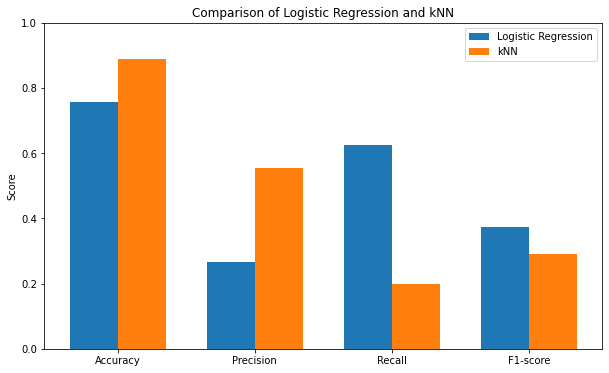

In [27]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    model_comparison.iloc[0][metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    model_comparison.iloc[1][metrics],
    width,
    label="kNN"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Comparison of Logistic Regression and kNN")
plt.ylim(0, 1)
plt.legend()

plt.show()

## conclusion: Bank Marketing model comparision
kNN achieved substantially higher overall accuracy and precision, but Logistic Regression achieved much higher recall and F1-score. Because the business objective is to identify customers who may subscribe to a term deposit, recall is particularly important because failing to identify a potential subscriber represents a missed marketing opportunity. Therefore, Logistic Regression may be more suitable when identifying potential subscribers is prioritised, despite its lower overall accuracy.

In [28]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-additional.csv', 'bank-full.csv', 'bank-names.txt', 'bank.csv', 'Case_Study.ipynb', 'default of credit card clients.xls']


In [29]:
# To install xlrd to read it because,it ensures the .xls file can be read.
!pip install xlrd

In [30]:
credit_df = pd.read_excel("default of credit card clients.xls", header=1)

print("Credit Card dataset loaded successfully!")
print("Number of rows:", credit_df.shape[0])
print("Number of columns:", credit_df.shape[1])

# Load the Credit Card Default dataset directly from the UCI Machine Learning Repository

# credit_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

# credit_df = pd.read_excel(credit_url, header=1)

# print("Credit Card Default dataset loaded successfully!")
# print("Number of rows:", credit_df.shape[0])
# print("Number of columns:", credit_df.shape[1])

Credit Card dataset loaded successfully!
Number of rows: 30000
Number of columns: 25


In [31]:
credit_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [32]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [33]:
credit_df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [34]:
print(credit_df["default payment next month"].value_counts())

0    23364
1     6636
Name: default payment next month, dtype: int64


In [35]:
print(credit_df["default payment next month"].value_counts(normalize=True) * 100)

0    77.88
1    22.12
Name: default payment next month, dtype: float64


In [36]:
credit_model = credit_df.copy()

print("Working copy created successfully!")
print(credit_model.shape)

Working copy created successfully!
(30000, 25)


In [37]:
credit_model = credit_model.drop(columns=["ID"])

print("ID column removed.")
print("Number of columns:", credit_model.shape[1])

ID column removed.
Number of columns: 24


In [38]:
credit_model = credit_model.rename(
    columns={"default payment next month": "default"}
)

print(credit_model.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [39]:
X_credit = credit_model.drop(columns=["default"])
y_credit = credit_model["default"]

print("X shape:", X_credit.shape)
print("y shape:", y_credit.shape)

X shape: (30000, 23)
y shape: (30000,)


In [40]:
categorical_credit = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_credit = [
    col for col in X_credit.columns
    if col not in categorical_credit
]

print("Categorical features:")
print(categorical_credit)

print("\nNumerical features:")
print(numeric_credit)

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE']

Numerical features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [41]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.20,
    random_state=42,
    stratify=y_credit
)

print("Training data:", Xc_train.shape)
print("Testing data:", Xc_test.shape)

Training data: (24000, 23)
Testing data: (6000, 23)


In [42]:
credit_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_credit
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_credit
        )
    ]
)

print("Credit dataset preprocessing system created!")

Credit dataset preprocessing system created!


Dataset 1

Will a customer subscribe to a term deposit?

Dataset 2

Will a customer default on their credit-card payment?

In [43]:
credit_logistic_model = Pipeline([
    ("preprocessing", credit_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

print("Credit Logistic Regression model created!")

Credit Logistic Regression model created!


In [44]:
credit_logistic_model.fit(Xc_train, yc_train)

print("Credit Logistic Regression training completed!")

Credit Logistic Regression training completed!


In [45]:
credit_logistic_predictions = credit_logistic_model.predict(Xc_test)

print("Predictions generated!")
print(credit_logistic_predictions[:20])

Predictions generated!
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0]


0 = did not default
1 = defaulted

In [46]:
credit_logistic_accuracy = accuracy_score(
    yc_test,
    credit_logistic_predictions
)

credit_logistic_precision = precision_score(
    yc_test,
    credit_logistic_predictions
)

credit_logistic_recall = recall_score(
    yc_test,
    credit_logistic_predictions
)

credit_logistic_f1 = f1_score(
    yc_test,
    credit_logistic_predictions
)

print("Credit Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", round(credit_logistic_accuracy, 4))
print("Precision:", round(credit_logistic_precision, 4))
print("Recall   :", round(credit_logistic_recall, 4))
print("F1-score :", round(credit_logistic_f1, 4))

Credit Logistic Regression Results
-----------------------------------
Accuracy : 0.6783
Precision: 0.3678
Recall   : 0.6323
F1-score : 0.4651


In [47]:
credit_logistic_cm = confusion_matrix(
    yc_test,
    credit_logistic_predictions
)

print("Credit Logistic Regression Confusion Matrix:")
print(credit_logistic_cm)

Credit Logistic Regression Confusion Matrix:
[[3231 1442]
 [ 488  839]]


In [48]:
credit_knn_model = Pipeline([
    ("preprocessing", credit_preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

print("Credit kNN model created!")

Credit kNN model created!


In [49]:
credit_knn_model.fit(Xc_train, yc_train)

print("Credit kNN training completed!")

Credit kNN training completed!


In [50]:
credit_knn_predictions = credit_knn_model.predict(Xc_test)

print("Credit kNN predictions generated!")
print(credit_knn_predictions[:20])

Credit kNN predictions generated!
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [51]:
credit_knn_accuracy = accuracy_score(
    yc_test,
    credit_knn_predictions
)

credit_knn_precision = precision_score(
    yc_test,
    credit_knn_predictions
)

credit_knn_recall = recall_score(
    yc_test,
    credit_knn_predictions
)

credit_knn_f1 = f1_score(
    yc_test,
    credit_knn_predictions
)

print("Credit kNN Results")
print("------------------")
print("Accuracy :", round(credit_knn_accuracy, 4))
print("Precision:", round(credit_knn_precision, 4))
print("Recall   :", round(credit_knn_recall, 4))
print("F1-score :", round(credit_knn_f1, 4))

Credit kNN Results
------------------
Accuracy : 0.7948
Precision: 0.5561
Recall   : 0.3587
F1-score : 0.4361


In [52]:
credit_knn_cm = confusion_matrix(
    yc_test,
    credit_knn_predictions
)

print("Credit kNN Confusion Matrix:")
print(credit_knn_cm)

Credit kNN Confusion Matrix:
[[4293  380]
 [ 851  476]]


In [53]:
all_results = pd.DataFrame({
    "Dataset": [
        "Bank Marketing",
        "Bank Marketing",
        "Credit Card Default",
        "Credit Card Default"
    ],
    "Model": [
        "Logistic Regression",
        "kNN",
        "Logistic Regression",
        "kNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        credit_logistic_accuracy,
        credit_knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision,
        credit_logistic_precision,
        credit_knn_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall,
        credit_logistic_recall,
        credit_knn_recall
    ],
    "F1-score": [
        logistic_f1,
        knn_f1,
        credit_logistic_f1,
        credit_knn_f1
    ]
})

all_results.round(4)

,Dataset,Model,Accuracy,Precision,Recall,F1-score
0,Bank Marketing,Logistic Regression,0.7552,0.2666,0.6238,0.3735
1,Bank Marketing,kNN,0.8874,0.5529,0.1975,0.2911
2,Credit Card Default,Logistic Regression,0.6783,0.3678,0.6323,0.4651
3,Credit Card Default,kNN,0.7948,0.5561,0.3587,0.4361


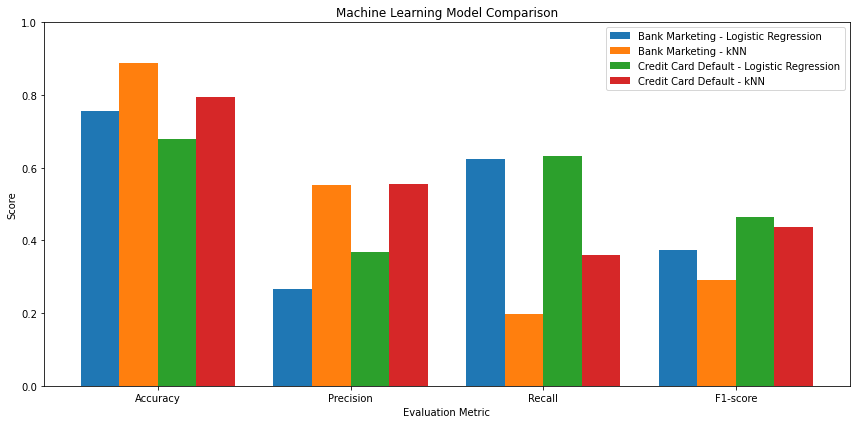

In [54]:
plot_data = all_results.copy()

plot_data["Model"] = (
    plot_data["Dataset"]
    + " - "
    + plot_data["Model"]
)

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12, 6))

for i, row in plot_data.iterrows():
    plt.bar(
        x + (i - 1.5) * width,
        row[metrics],
        width,
        label=row["Model"]
    )

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

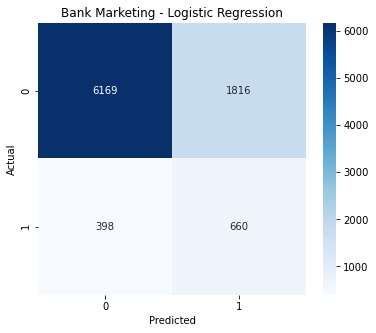

In [55]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Bank Marketing - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

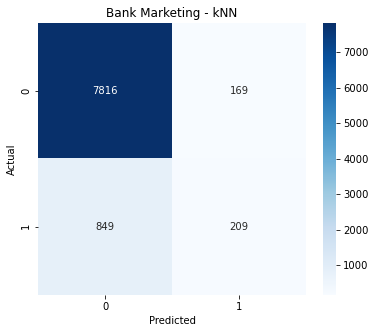

In [56]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Bank Marketing - kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

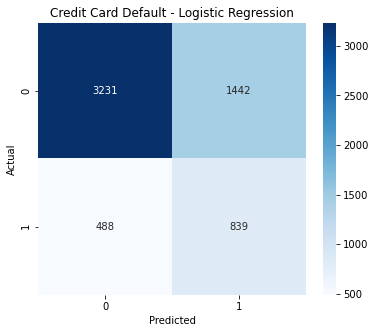

In [57]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    credit_logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Credit Card Default - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

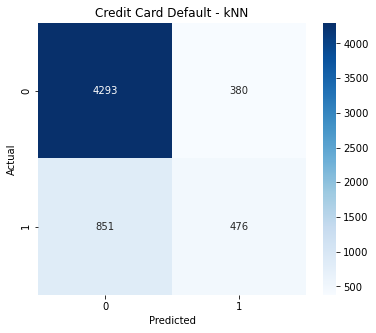

In [58]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    credit_knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Credit Card Default - kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Across both datasets, we see the same general pattern:

kNN provides higher accuracy and precision, while Logistic Regression provides higher recall.

That's a very good finding because it lets you discuss the models in terms of business priorities, rather than simply choosing the highest accuracy.

For marketing

If the organisation wants to capture as many potential subscribers as possible, Logistic Regression is more attractive because of its higher recall.

For credit risk

If the organisation wants to identify as many actual defaulters as possible, Logistic Regression is again more useful because of its higher recall.

However, kNN produces fewer false positive predictions and has substantially higher accuracy and precision.

In [59]:
# Get the fitted preprocessing system from the Logistic Regression pipeline
fitted_preprocessor = logistic_model.named_steps["preprocessing"]

# Numerical feature names
numeric_names = list(numeric_features)

# Get the fitted OneHotEncoder
fitted_encoder = fitted_preprocessor.named_transformers_["cat"]

# Get categorical feature names
try:
    categorical_names = list(
        fitted_encoder.get_feature_names_out(categorical_features)
    )
except AttributeError:
    categorical_names = list(
        fitted_encoder.get_feature_names(categorical_features)
    )

# Combine numerical and categorical feature names
bank_feature_names = numeric_names + categorical_names

# Get Logistic Regression coefficients
bank_coefficients = logistic_model.named_steps["model"].coef_[0]

# Create feature importance table
bank_feature_importance = pd.DataFrame({
    "Feature": bank_feature_names,
    "Coefficient": bank_coefficients
})

# Calculate absolute coefficient size
bank_feature_importance["Absolute_Coefficient"] = (
    bank_feature_importance["Coefficient"].abs()
)

# Sort by strongest coefficients
bank_feature_importance = bank_feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

bank_feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
48,poutcome_success,1.678861,1.678861
41,month_mar,1.194256,1.194256
38,month_jan,-1.051369,1.051369
44,month_oct,0.948865,0.948865
36,month_dec,0.865458,0.865458
43,month_nov,-0.787851,0.787851
45,month_sep,0.782210,0.782210
35,month_aug,-0.742264,0.742264
33,contact_unknown,-0.711453,0.711453
46,poutcome_failure,-0.666107,0.666107


In [60]:
bank_feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
48,poutcome_success,1.678861,1.678861
41,month_mar,1.194256,1.194256
38,month_jan,-1.051369,1.051369
44,month_oct,0.948865,0.948865
36,month_dec,0.865458,0.865458
43,month_nov,-0.787851,0.787851
45,month_sep,0.782210,0.782210
35,month_aug,-0.742264,0.742264
33,contact_unknown,-0.711453,0.711453
46,poutcome_failure,-0.666107,0.666107


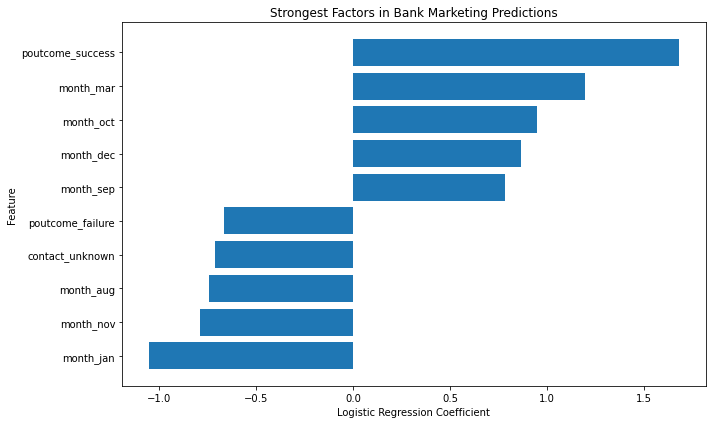

In [61]:
top_bank_features = bank_feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_bank_features["Feature"],
    top_bank_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Strongest Factors in Bank Marketing Predictions")

plt.tight_layout()
plt.show()

In [62]:
bank_job_response = pd.crosstab(
    bank_df["job"],
    bank_df["y"],
    normalize="index"
) * 100

bank_job_response = bank_job_response.sort_values(
    "yes",
    ascending=False
)

bank_job_response

y,no,yes
job,,
student,71.321962,28.678038
retired,77.208481,22.791519
unemployed,84.497314,15.502686
management,86.244449,13.755551
admin.,87.797331,12.202669
self-employed,88.157061,11.842939
unknown,88.194444,11.805556
technician,88.943004,11.056996
services,91.116996,8.883004


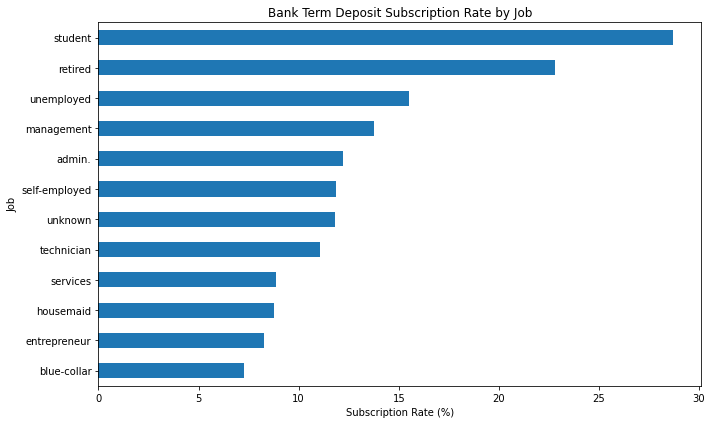

In [63]:
plt.figure(figsize=(10, 6))

bank_job_response["yes"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.title("Bank Term Deposit Subscription Rate by Job")

plt.tight_layout()
plt.show()

In [64]:
bank_job_response

y,no,yes
job,,
student,71.321962,28.678038
retired,77.208481,22.791519
unemployed,84.497314,15.502686
management,86.244449,13.755551
admin.,87.797331,12.202669
self-employed,88.157061,11.842939
unknown,88.194444,11.805556
technician,88.943004,11.056996
services,91.116996,8.883004


The student group has the highest observed subscription rate at 28.68%, followed by retired customers at 22.79%. Blue-collar customers have the lowest rate at 7.27%.

This supports the idea that customer characteristics are associated with different responses to the bank's marketing campaign.

 Notice that we're saying "associated with", not "caused". That's important.

Combined with our Logistic Regression result where poutcome_success had the strongest coefficient, we now have two useful findings:

Bank Marketing Insight 1

Previous campaign success is the strongest feature in our Logistic Regression model, suggesting that previous campaign outcomes are highly informative when identifying potential subscribers.

Bank Marketing Insight 2

Subscription rates differ substantially between job groups, with students and retired customers showing considerably higher observed subscription rates than blue-collar customers.

In [65]:
# Get the fitted preprocessing system
credit_preprocessor_fitted = credit_logistic_model.named_steps["preprocessing"]

# Numerical feature names
credit_numeric_names = list(numeric_credit)

# Get the fitted OneHotEncoder
credit_encoder = credit_preprocessor_fitted.named_transformers_["cat"]

# Get categorical feature names
try:
    credit_categorical_names = list(
        credit_encoder.get_feature_names_out(categorical_credit)
    )
except AttributeError:
    credit_categorical_names = list(
        credit_encoder.get_feature_names(categorical_credit)
    )

# Combine all feature names
credit_feature_names = (
    credit_numeric_names + credit_categorical_names
)

# Get Logistic Regression coefficients
credit_coefficients = (
    credit_logistic_model.named_steps["model"].coef_[0]
)

# Create feature importance table
credit_feature_importance = pd.DataFrame({
    "Feature": credit_feature_names,
    "Coefficient": credit_coefficients
})

# Calculate absolute coefficient
credit_feature_importance["Absolute_Coefficient"] = (
    credit_feature_importance["Coefficient"].abs()
)

# Sort by strongest coefficients
credit_feature_importance = credit_feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

credit_feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
22,EDUCATION_0,-0.952238,0.952238
27,EDUCATION_5,-0.763495,0.763495
29,MARRIAGE_0,-0.636345,0.636345
23,EDUCATION_1,0.607710,0.607710
2,PAY_0,0.589576,0.589576
24,EDUCATION_2,0.520623,0.520623
25,EDUCATION_3,0.457355,0.457355
28,EDUCATION_6,0.451232,0.451232
26,EDUCATION_4,-0.313259,0.313259
8,BILL_AMT1,-0.290849,0.290849


In [66]:
credit_feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
22,EDUCATION_0,-0.952238,0.952238
27,EDUCATION_5,-0.763495,0.763495
29,MARRIAGE_0,-0.636345,0.636345
23,EDUCATION_1,0.607710,0.607710
2,PAY_0,0.589576,0.589576
24,EDUCATION_2,0.520623,0.520623
25,EDUCATION_3,0.457355,0.457355
28,EDUCATION_6,0.451232,0.451232
26,EDUCATION_4,-0.313259,0.313259
8,BILL_AMT1,-0.290849,0.290849


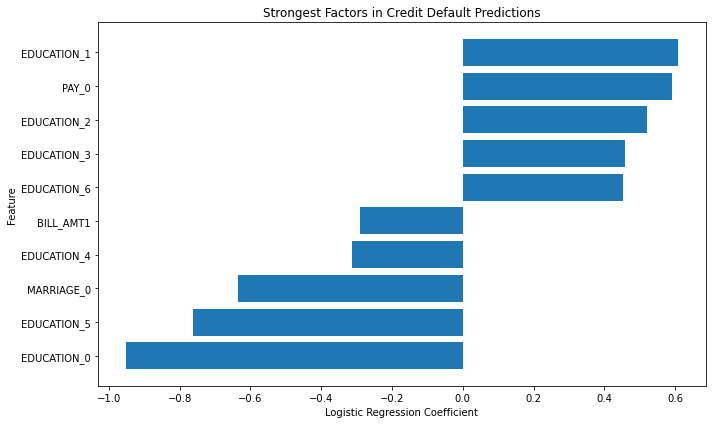

In [67]:
top_credit_features = credit_feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_credit_features["Feature"],
    top_credit_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Strongest Factors in Credit Default Predictions")

plt.tight_layout()
plt.show()

In [68]:
education_default = pd.crosstab(
    credit_df["EDUCATION"],
    credit_df["default payment next month"],
    normalize="index"
) * 100

education_default = education_default.sort_values(
    1,
    ascending=False
)

education_default

default payment next month,0,1
EDUCATION,,
3,74.842384,25.157616
2,76.265146,23.734854
1,80.765234,19.234766
6,84.313725,15.686275
5,93.571429,6.428571
4,94.308943,5.691057
0,100.000000,0.000000


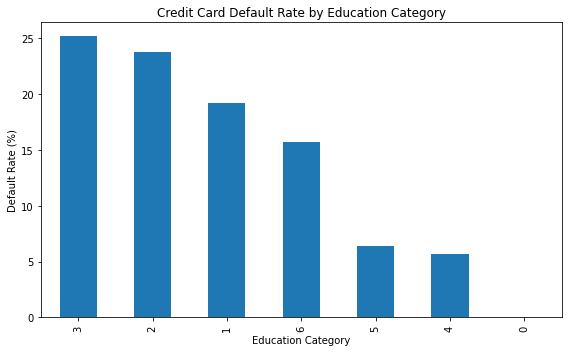

In [69]:
plt.figure(figsize=(8, 5))

education_default[1].plot(
    kind="bar"
)

plt.xlabel("Education Category")
plt.ylabel("Default Rate (%)")
plt.title("Credit Card Default Rate by Education Category")

plt.tight_layout()
plt.show()

In [70]:
education_default

default payment next month,0,1
EDUCATION,,
3,74.842384,25.157616
2,76.265146,23.734854
1,80.765234,19.234766
6,84.313725,15.686275
5,93.571429,6.428571
4,94.308943,5.691057
0,100.000000,0.000000


# For dataset 1 Bank marketing
Insight 1: Previous campaign success was the strongest feature in the Logistic Regression model, with a coefficient of 1.6789.

Insight 2: Customer job groups showed substantial differences in observed subscription rates. Students had the highest rate (28.68 percentage) and blue-collar customers the lowest (7.27 percentages).

Insight 3: kNN achieved much higher accuracy and precision, but Logistic Regression achieved much higher recall. Therefore, the preferred model depends on whether the bank prioritises overall prediction accuracy or finding as many potential subscribers as possible.

# For dataset 2 Credit card default
Insight 1: PAY_0, representing recent repayment status, was one of the strongest clearly interpretable numerical predictors in the Logistic Regression model, with a coefficient of 0.5896.

Insight 2: Education categories showed different observed default rates, with categories 3 and 2 having the highest rates at approximately 25.2 percentage and 23.7 percentage.

Insight 3: Again, kNN achieved better accuracy and precision, while Logistic Regression achieved substantially better recall.

# Conclusion:
Across both financial datasets, kNN produced higher accuracy and precision, while Logistic Regression consistently produced higher recall. This shows that model effectiveness depends on the business objective rather than accuracy alone. Logistic Regression may be preferable when identifying as many positive cases as possible is important, while kNN may be preferable when overall correctness and reducing false positive predictions are prioritised.

In [72]:
all_results.round(4)

,Dataset,Model,Accuracy,Precision,Recall,F1-score
0,Bank Marketing,Logistic Regression,0.7552,0.2666,0.6238,0.3735
1,Bank Marketing,kNN,0.8874,0.5529,0.1975,0.2911
2,Credit Card Default,Logistic Regression,0.6783,0.3678,0.6323,0.4651
3,Credit Card Default,kNN,0.7948,0.5561,0.3587,0.4361
